# AutoScout24 Secondary Dataset EDA

This notebook performs exploratory data analysis on the latest `scrape_audi_q4_*_secondary.csv` before any preprocessing.

The `_secondary.csv` file is treated as the canonical input here because it already contains:
- primary listing fields
- secondary detail-page fields
- scrape health columns

This notebook is analysis-only:
- no preprocessing writes
- no exported charts
- no summary CSV outputs
- all outputs stay inside notebook cells

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 120)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)

CSV_PATTERN = 'scrape_audi_q4_*_secondary.csv'

SECONDARY_DETAIL_COLUMNS = [
    'warranty_exists',
    'warranty_text',
    'has_full_service_history',
    'had_accident',
    'damage_conditions',
    'previous_owner_count',
    'body_type',
    'door_count',
    'seat_count',
    'exterior_color',
    'paint_type',
    'interior_color',
    'upholstery_material',
    'battery_ownership',
    'battery_charging_time',
    'electric_range',
    'electric_range_city',
]

SCRAPE_STATUS_COLUMNS = ['secondary_scrape_status', 'secondary_scrape_error']

NUMERIC_LIKE_COLUMNS = [
    'price',
    'power_kw',
    'power_hp',
    'seller_rating_stars',
    'seller_rating_count',
    'image_count',
    'previous_owner_count',
    'door_count',
    'seat_count',
]

SECONDARY_CATEGORICAL_COLUMNS = [
    'warranty_exists',
    'has_full_service_history',
    'had_accident',
    'damage_conditions',
    'body_type',
    'exterior_color',
    'paint_type',
    'interior_color',
    'upholstery_material',
    'battery_ownership',
]

INHERITED_CONTEXT_COLUMNS = [
    'seller_type',
    'country_code',
    'fuel_or_powertrain',
    'variant',
]


def display_section(title, text=None, level=2):
    prefix = '#' * level
    content = f'{prefix} {title}'
    if text:
        content += f'\n\n{text}'
    display(Markdown(content))


def preview_list(values, limit=12):
    items = [str(value) for value in values if value is not None]
    if not items:
        return 'None'
    if len(items) <= limit:
        return ', '.join(items)
    return ', '.join(items[:limit]) + f', ... (+{len(items) - limit} more)'


def find_latest_secondary_csv():
    roots = []
    cwd = Path.cwd().resolve()
    roots.append(cwd)
    if cwd.parent != cwd:
        roots.append(cwd.parent)

    candidates = []
    seen = set()
    for root in roots:
        for path in root.rglob(CSV_PATTERN):
            resolved = path.resolve()
            if resolved not in seen:
                seen.add(resolved)
                candidates.append(resolved)

    if not candidates:
        searched = '\n'.join(f'- {root}' for root in roots)
        raise FileNotFoundError(
            'No secondary CSV matching scrape_audi_q4_*_secondary.csv was found.\n'
            f'Searched in:\n{searched}'
        )

    return max(candidates, key=lambda path: path.stat().st_mtime)


def extract_numeric_series(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce')

    text = series.astype(str)
    extracted = text.str.extract(r'([-+]?\d[\d,\.]*)', expand=False)
    cleaned = extracted.str.replace(',', '', regex=False)
    return pd.to_numeric(cleaned, errors='coerce')


def build_missingness_table(dataframe):
    table = pd.DataFrame({
        'null_count': dataframe.isna().sum(),
        'null_pct': dataframe.isna().mean() * 100,
        'non_null_count': dataframe.notna().sum(),
    })
    return table.sort_values(['null_count', 'null_pct'], ascending=False)


def build_uniqueness_table(dataframe):
    unique_count = dataframe.nunique(dropna=True)
    dominant_share = dataframe.apply(
        lambda col: col.value_counts(dropna=False, normalize=True).iloc[0] * 100 if len(col) else np.nan
    )
    table = pd.DataFrame({
        'unique_count': unique_count,
        'dominant_value_pct': dominant_share,
    })
    return table.sort_values(['unique_count', 'dominant_value_pct'], ascending=[True, False])


def show_top_categories(dataframe, column, top_n=10):
    if column not in dataframe.columns:
        print(f'Skipping missing column: {column}')
        return

    series = dataframe[column].fillna('<Missing>').astype(str)
    counts = series.value_counts(dropna=False).head(top_n)
    summary = pd.DataFrame({
        'count': counts,
        'pct': counts / len(dataframe) * 100,
    })

    display_section(f'Categorical profile: {column}', level=3)
    display(summary)

    plt.figure(figsize=(10, 4))
    sns.barplot(x=summary.index.astype(str), y=summary['count'], color='#4C78A8')
    plt.title(f'Top values for {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def show_crosstab(dataframe, row_col, col_col, top_rows=None, top_cols=None):
    if row_col not in dataframe.columns or col_col not in dataframe.columns:
        print(f'Skipping cross-tab for missing columns: {row_col}, {col_col}')
        return

    temp = dataframe[[row_col, col_col]].copy()
    temp[row_col] = temp[row_col].fillna('<Missing>').astype(str)
    temp[col_col] = temp[col_col].fillna('<Missing>').astype(str)

    if top_rows is not None:
        top_row_values = temp[row_col].value_counts().head(top_rows).index
        temp = temp[temp[row_col].isin(top_row_values)]

    if top_cols is not None:
        top_col_values = temp[col_col].value_counts().head(top_cols).index
        temp = temp[temp[col_col].isin(top_col_values)]

    table = pd.crosstab(temp[row_col], temp[col_col])
    display_section(f'Cross-tab: {row_col} x {col_col}', level=3)
    display(table)

    if table.empty:
        print('No rows available after filtering.')
        return

    if table.shape[0] <= 12 and table.shape[1] <= 12:
        plt.figure(figsize=(max(8, table.shape[1] * 1.2), max(4, table.shape[0] * 0.6)))
        sns.heatmap(table, annot=True, fmt='g', cmap='Blues')
        plt.title(f'{row_col} x {col_col}')
        plt.tight_layout()
        plt.show()
    else:
        table.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='tab20')
        plt.title(f'{row_col} x {col_col}')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()


In [6]:
secondary_csv_path = find_latest_secondary_csv()
raw_df = pd.read_csv(secondary_csv_path)

display_section('Loaded dataset')
print(f'Selected file: {secondary_csv_path}')
print(f'Shape: {raw_df.shape[0]} rows x {raw_df.shape[1]} columns')
display(raw_df.head())

primary_listing_columns = [
    column for column in raw_df.columns
    if column not in SECONDARY_DETAIL_COLUMNS + SCRAPE_STATUS_COLUMNS
]

structure_text = (
    f'- Primary listing columns ({len(primary_listing_columns)}): {preview_list(primary_listing_columns)}\n'
    f'- Secondary detail columns ({len([c for c in SECONDARY_DETAIL_COLUMNS if c in raw_df.columns])}): {preview_list([c for c in SECONDARY_DETAIL_COLUMNS if c in raw_df.columns])}\n'
    f'- Scrape-status columns ({len([c for c in SCRAPE_STATUS_COLUMNS if c in raw_df.columns])}): {preview_list([c for c in SCRAPE_STATUS_COLUMNS if c in raw_df.columns])}'
)
display_section('Dataset structure overview', text=structure_text)

structure_table = pd.DataFrame({
    'column': raw_df.columns,
    'dtype': raw_df.dtypes.astype(str).values,
    'non_null_count': raw_df.notna().sum().values,
    'null_count': raw_df.isna().sum().values,
    'null_pct': (raw_df.isna().mean() * 100).values,
})
display(structure_table)

memory_usage = raw_df.memory_usage(deep=True).sort_values(ascending=False)
memory_table = pd.DataFrame({
    'column': memory_usage.index.astype(str),
    'bytes': memory_usage.values,
    'megabytes': memory_usage.values / (1024 ** 2),
})
display_section('Memory usage summary', level=3)
display(memory_table)


## Loaded dataset

Selected file: /Users/vakof/Desktop/HOD_car/HOD_car/Scrape/scrape_audi_q4_20260509_secondary.csv
Shape: 1321 rows x 57 columns


,listing_id,title,subtitle,variant,model_group,transmission,price,currency,price_superscript,is_conditional_price,mileage,first_registration,fuel_or_powertrain,power_kw,power_hp,wltp_consumption,wltp_co2_emissions,seller_name,seller_type,dealer_id,seller_phone,seller_rating_stars,seller_rating_count,seller_info_url,seller_imprint_url,seller_location,country_code,zip_code,city,street,image_count,primary_image_url,has_360_image,available_now,vat_deductible,delivery_possible,listing_url,raw_card_text,warranty_exists,warranty_text,has_full_service_history,had_accident,damage_conditions,previous_owner_count,body_type,door_count,seat_count,exterior_color,paint_type,interior_color,upholstery_material,battery_ownership,battery_charging_time,electric_range,electric_range_city,secondary_scrape_status,secondary_scrape_error
0,b22aed95-cacd-4d1c-bab4-b9fd6b2c267a,Audi Q4 e-tron 50 quattro,50 quattro,Q4 e-tron,Q4 e-tron,Automatic,"36,870",€,1.0,False,"31,618 km",12/2023,Electric,220,299,NaN,NaN,DB Autohaus Schweinfurt Premium,Dealer,17009627,+49 (0)9721 - 65040,4.0,49.0,https://www.autoscout24.com/dealerinfo/db-autohaus-schweinfurt-premium?atype=C,https://www.autoscout24.com/dealerinfo/db-autohaus-schweinfurt-premium/imprint,DE-97424 Schweinfurt,DE,97424,Schweinfurt,Friedrich-Rätzer-Straße 10,38,https://prod.pictures.autoscout24.net/listing-images/b22aed95-cacd-4d1c-bab4-b9fd6b2c267a_471f99a7-2f88-45e6-a79b-1a...,NaN,True,NaN,NaN,https://www.autoscout24.com/offers/audi-q4-e-tron-50-quattro-electric-black-b22aed95-cacd-4d1c-bab4-b9fd6b2c267a,"Audi Q4 e-tron 50 quattro Add to list 38 € 36,8701 From 285 € p.m. financing From 12,41 € p.m. insurance 12/2023 31,...",True,12 months,True,False,NaN,1.0,SUV/Off-Road/Pick-Up,5.0,5.0,Black,Metallic,Brown,Part leather,NaN,NaN,NaN,NaN,ok,NaN
1,cc3a2419-5041-4d83-9f9e-ad20511f8fc4,Audi Q4 e-tron Sportback 50 quattro 82 kWh,Sportback 50 quattro 82 kWh,Q4 e-tron Sportback,Q4 e-tron,Automatic,"38,990",€,1.0,False,"17,077 km",01/2024,Electric,220,299,NaN,NaN,DB Autohaus Schweinfurt Premium,Dealer,17009627,+49 (0)9721 - 65040,4.0,49.0,https://www.autoscout24.com/dealerinfo/db-autohaus-schweinfurt-premium?atype=C,https://www.autoscout24.com/dealerinfo/db-autohaus-schweinfurt-premium/imprint,DE-97424 Schweinfurt,DE,97424,Schweinfurt,Friedrich-Rätzer-Straße 10,39,https://prod.pictures.autoscout24.net/listing-images/cc3a2419-5041-4d83-9f9e-ad20511f8fc4_8fa96b3c-4051-48d9-a2a0-ad...,NaN,True,NaN,NaN,https://www.autoscout24.com/offers/audi-q4-e-tron-sportback-50-quattro-82-kwh-electric-blue-cc3a2419-5041-4d83-9f9e-...,"Audi Q4 e-tron Sportback 50 quattro 82 kWh Add to list 39 € 38,9901 From 290 € p.m. financing From 12,41 € p.m. insu...",True,12 months,True,False,NaN,1.0,SUV/Off-Road/Pick-Up,5.0,5.0,Blue,Metallic,Brown,Part leather,NaN,NaN,NaN,NaN,ok,NaN
2,5e239b7a-4001-4ddd-a84c-447f37d94879,Audi Q4 e-tron S line 45 quattro MATRIX PANO ACC A,S line 45 quattro MATRIX PANO ACC A,Q4 e-tron,Q4 e-tron,Automatic,"36,490",€,1.0,False,"48,691 km",03/2023,Electric,195,265,NaN,NaN,Audi Zentrum Potsdam,Dealer,17291342,+49 (0)331 - 7486105,4.5,41.0,https://www.autoscout24.com/dealerinfo/audi-zentrum-potsdam?atype=C,https://www.autoscout24.com/dealerinfo/audi-zentrum-potsdam/imprint,DE-14482 Potsdam,DE,14482,Potsdam,Fritz-Zubeil-Straße 70-78,9,https://prod.pictures.autoscout24.net/listing-images/5e239b7a-4001-4ddd-a84c-447f37d94879_62389173-684d-4783-8c72-34...,NaN,True,NaN,NaN,https://www.autoscout24.com/offers/audi-q4-e-tron-s-line-45-quattro-matrix-pano-acc-a-electric-blue-5e239b7a-4001-4d...,"Audi Q4 e-tron S line 45 quattro MATRIX PANO ACC A Add to list 9 € 36,4901 From 518 € p.m. financing From 12,41 € p....",True,NaN,True,False,NaN,1.0,SUV/Off-Road/Pick-Up,5.0,5.0,Blue,Metallic,Beige,Full leather,NaN,NaN,412 km,NaN,ok,NaN
3,b4efaef0-ba65-46a3-bc90-d8dd768164e2,Audi Q4 e-tron Q4 Sportback 45 e-tron Matrix AHK Connect,Q4 Sportback 45 e-tron Matrix AHK Connect,Q4 e-tron Sportback,Q4 e-tron,Automatic,"46,460",€,1.0,False,"2

## Dataset structure overview

- Primary listing columns (38): listing_id, title, subtitle, variant, model_group, transmission, price, currency, price_superscript, is_conditional_price, mileage, first_registration, ... (+26 more)
- Secondary detail columns (17): warranty_exists, warranty_text, has_full_service_history, had_accident, damage_conditions, previous_owner_count, body_type, door_count, seat_count, exterior_color, paint_type, interior_color, ... (+5 more)
- Scrape-status columns (2): secondary_scrape_status, secondary_scrape_error

,column,dtype,non_null_count,null_count,null_pct
0,listing_id,object,1321,0,0.000000
1,title,object,1321,0,0.000000
2,subtitle,object,1321,0,0.000000
3,variant,object,1321,0,0.000000
4,model_group,object,1321,0,0.000000
5,transmission,object,1321,0,0.000000
6,price,object,1321,0,0.000000
7,currency,object,1321,0,0.000000
8,price_superscript,float64,1260,61,4.617714
9,is_conditional_price,bool,1321,0,0.000000


### Memory usage summary

,column,bytes,megabytes
0,primary_image_url,251392,0.239746
1,listing_url,243311,0.232039
2,seller_info_url,169984,0.162109
3,seller_imprint_url,167779,0.160007
4,title,132152,0.126030
5,subtitle,112932,0.107700
6,listing_id,112285,0.107083
7,seller_name,101381,0.096684
8,street,96010,0.091562
9,seller_location,92328,0.088051


In [7]:
display_section('Basic data quality checks')

duplicate_full_rows = int(raw_df.duplicated().sum())
duplicate_listing_url = int(raw_df.duplicated(subset=['listing_url']).sum()) if 'listing_url' in raw_df.columns else None
duplicate_listing_id = int(raw_df.duplicated(subset=['listing_id']).sum()) if 'listing_id' in raw_df.columns else None

quality_summary = pd.DataFrame({
    'metric': ['Duplicate full rows', 'Duplicate listing_url', 'Duplicate listing_id'],
    'value': [duplicate_full_rows, duplicate_listing_url, duplicate_listing_id],
})
display(quality_summary)

missingness_table = build_missingness_table(raw_df)
display_section('Missing-value table', level=3)
display(missingness_table)

uniqueness_table = build_uniqueness_table(raw_df)
display_section('Unique-count and dominance table', level=3)
display(uniqueness_table)

constant_columns = uniqueness_table[uniqueness_table['unique_count'] <= 1].index.tolist()
near_constant_columns = uniqueness_table[(uniqueness_table['unique_count'] > 1) & (uniqueness_table['dominant_value_pct'] >= 95)].index.tolist()

constant_text = (
    f'- Constant columns ({len(constant_columns)}): {preview_list(constant_columns)}\n'
    f'- Near-constant columns with >=95% dominant value ({len(near_constant_columns)}): {preview_list(near_constant_columns)}'
)
display_section('Constant and near-constant columns', text=constant_text, level=3)


## Basic data quality checks

,metric,value
0,Duplicate full rows,0
1,Duplicate listing_url,0
2,Duplicate listing_id,0


### Missing-value table

,null_count,null_pct,non_null_count
vat_deductible,1321,100.000000,0
secondary_scrape_error,1321,100.000000,0
delivery_possible,1312,99.318698,9
has_360_image,1307,98.940197,14
raw_card_text,1301,98.485995,20
damage_conditions,1253,94.852385,68
battery_charging_time,1244,94.171083,77
electric_range_city,1241,93.943982,80
battery_ownership,1220,92.354277,101
warranty_text,975,73.807721,346


### Unique-count and dominance table

,unique_count,dominant_value_pct
vat_deductible,0,100.000000
secondary_scrape_error,0,100.000000
model_group,1,100.000000
currency,1,100.000000
country_code,1,100.000000
secondary_scrape_status,1,100.000000
delivery_possible,1,99.318698
has_360_image,1,98.940197
available_now,1,96.896291
price_superscript,1,95.382286


### Constant and near-constant columns

- Constant columns (13): vat_deductible, secondary_scrape_error, model_group, currency, country_code, secondary_scrape_status, delivery_possible, has_360_image, available_now, price_superscript, damage_conditions, battery_ownership, ... (+1 more)
- Near-constant columns with >=95% dominant value (6): fuel_or_powertrain, transmission, is_conditional_price, seller_type, body_type, raw_card_text

## Scrape health and collection diagnostics

,count,pct
secondary_scrape_status,,
ok,1321,100.0


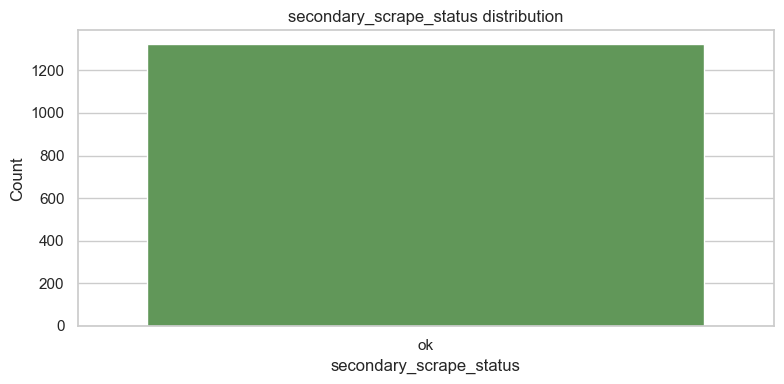

### Collection-quality signals

- Successful detail-page scrape rate: 100.00%
- Duplicate listing_url rows: 0
- Rows with recorded scrape errors: 0

In [8]:
display_section('Scrape health and collection diagnostics')

if 'secondary_scrape_status' in raw_df.columns:
    status_counts = raw_df['secondary_scrape_status'].fillna('<Missing>').value_counts(dropna=False)
    status_table = pd.DataFrame({
        'count': status_counts,
        'pct': status_counts / len(raw_df) * 100,
    })
    display(status_table)

    plt.figure(figsize=(8, 4))
    sns.barplot(x=status_table.index.astype(str), y=status_table['count'], color='#59A14F')
    plt.title('secondary_scrape_status distribution')
    plt.xlabel('secondary_scrape_status')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

if 'secondary_scrape_error' in raw_df.columns:
    error_cols = [col for col in ['listing_url', 'secondary_scrape_status', 'secondary_scrape_error'] if col in raw_df.columns]
    error_sample = raw_df.loc[raw_df['secondary_scrape_error'].notna(), error_cols].head(10)
    error_counts = raw_df['secondary_scrape_error'].dropna().astype(str).value_counts().head(10)

    if not error_counts.empty:
        display_section('Top scrape errors', level=3)
        display(pd.DataFrame({'count': error_counts, 'pct': error_counts / len(raw_df) * 100}))

    if not error_sample.empty:
        display_section('Sample rows with scrape errors', level=3)
        display(error_sample)

collection_notes = []
if 'secondary_scrape_status' in raw_df.columns:
    status_ok_pct = (raw_df['secondary_scrape_status'].astype(str).str.lower() == 'ok').mean() * 100
    collection_notes.append(f'Successful detail-page scrape rate: {status_ok_pct:.2f}%')
if duplicate_listing_url is not None:
    collection_notes.append(f'Duplicate listing_url rows: {duplicate_listing_url}')
if 'secondary_scrape_error' in raw_df.columns:
    error_row_count = int(raw_df['secondary_scrape_error'].notna().sum())
    collection_notes.append(f'Rows with recorded scrape errors: {error_row_count}')

display_section('Collection-quality signals', text='\n'.join(f'- {note}' for note in collection_notes), level=3)


## Numeric field profiling

,count,mean,std,min,25%,50%,75%,max,non_null_count,null_pct
price,1321.0,39099.557154,9749.633033,22790.0,30990.0,37840.0,45690.0,79900.0,1321,0.000000
power_kw,1321.0,179.532173,37.669887,70.0,150.0,195.0,210.0,250.0,1321,0.000000
power_hp,1321.0,244.257381,51.305772,95.0,204.0,265.0,286.0,340.0,1321,0.000000
seller_rating_stars,1229.0,4.465012,0.441621,3.0,4.5,4.5,5.0,5.0,1229,6.964421
seller_rating_count,1229.0,98.541904,171.798337,1.0,14.0,44.0,99.0,1683.0,1229,6.964421
image_count,1321.0,13.123391,4.902140,0.0,11.0,15.0,15.0,39.0,1321,0.000000
previous_owner_count,1277.0,1.043853,0.230075,0.0,1.0,1.0,1.0,3.0,1277,3.330810
door_count,1311.0,4.839817,0.366916,4.0,5.0,5.0,5.0,5.0,1311,0.757002
seat_count,1247.0,4.994387,0.074742,4.0,5.0,5.0,5.0,5.0,1247,5.601817


### Numeric parsing notes

The notebook converts numeric-like text columns in a local analysis copy only. Columns parsed from text: price

### Distribution: price

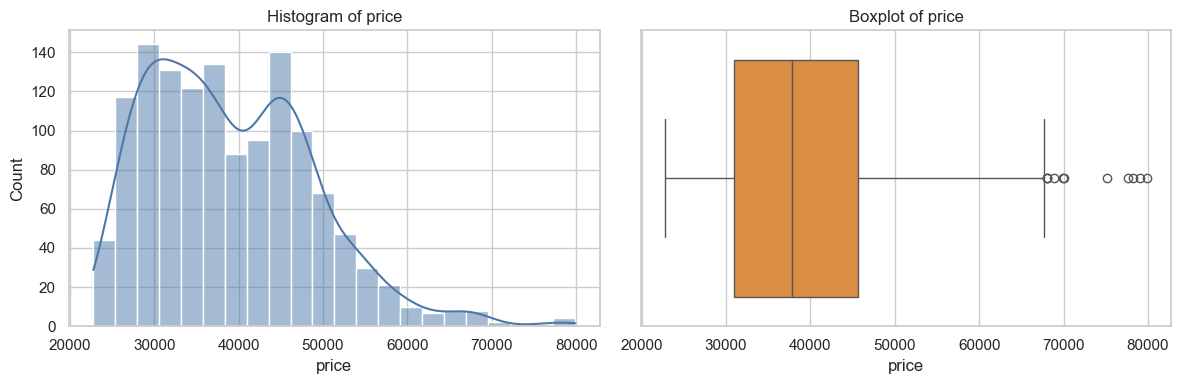

### Distribution: power_kw

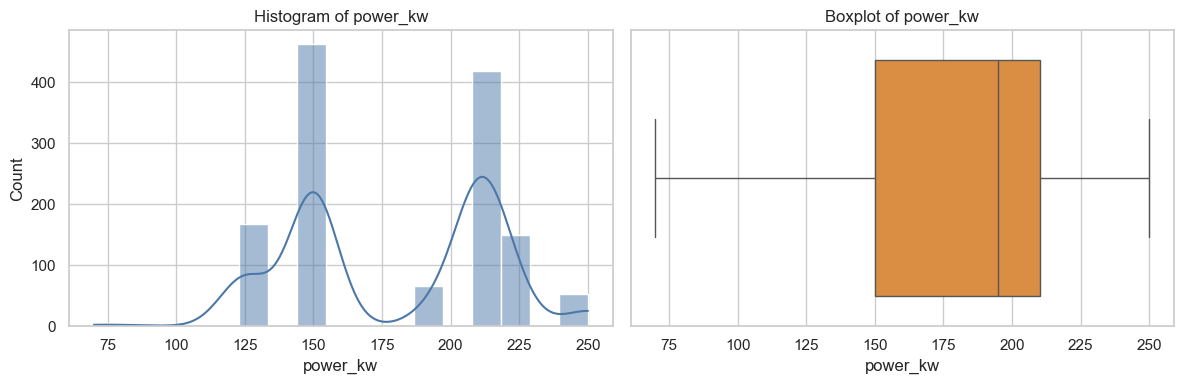

### Distribution: power_hp

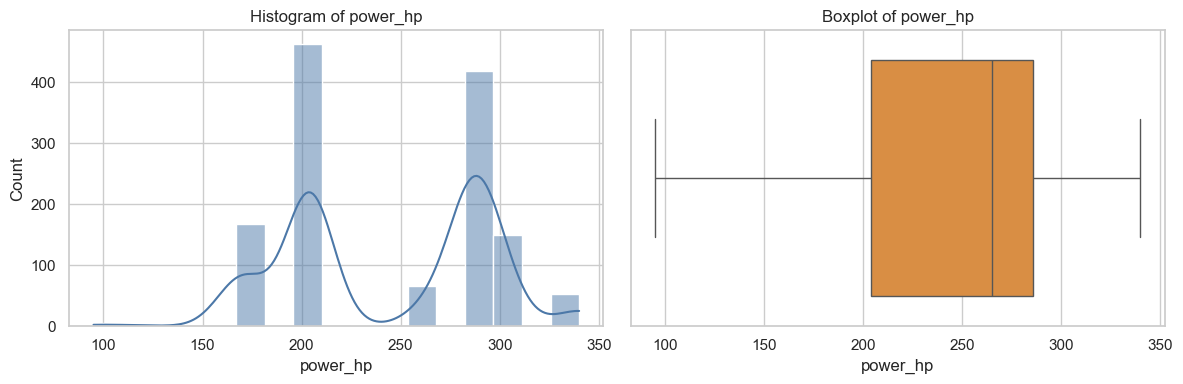

### Distribution: seller_rating_stars

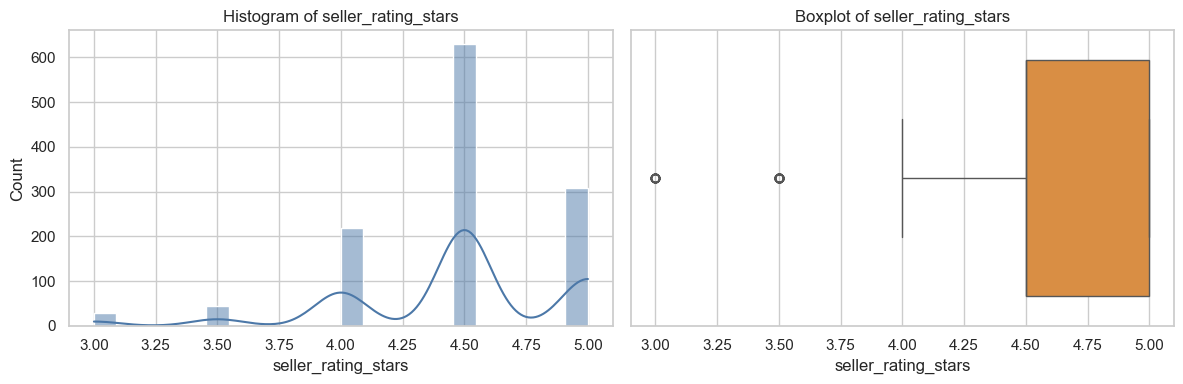

### Distribution: seller_rating_count

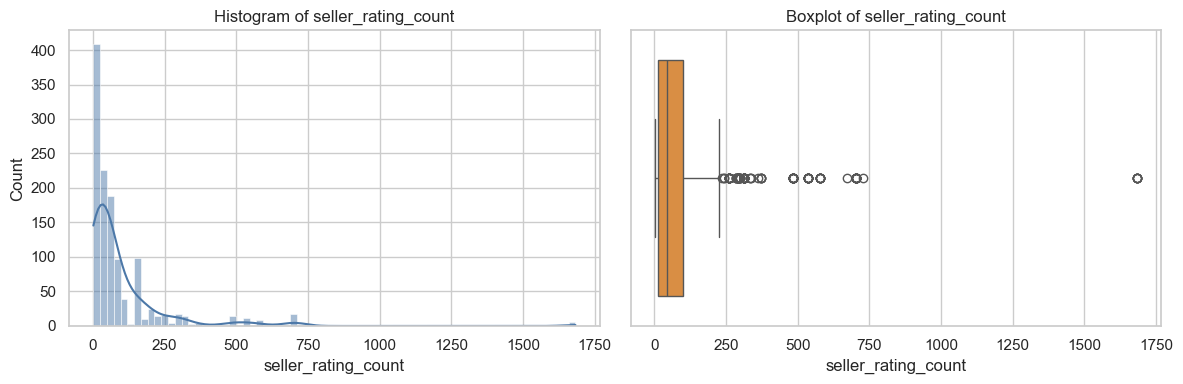

### Distribution: image_count

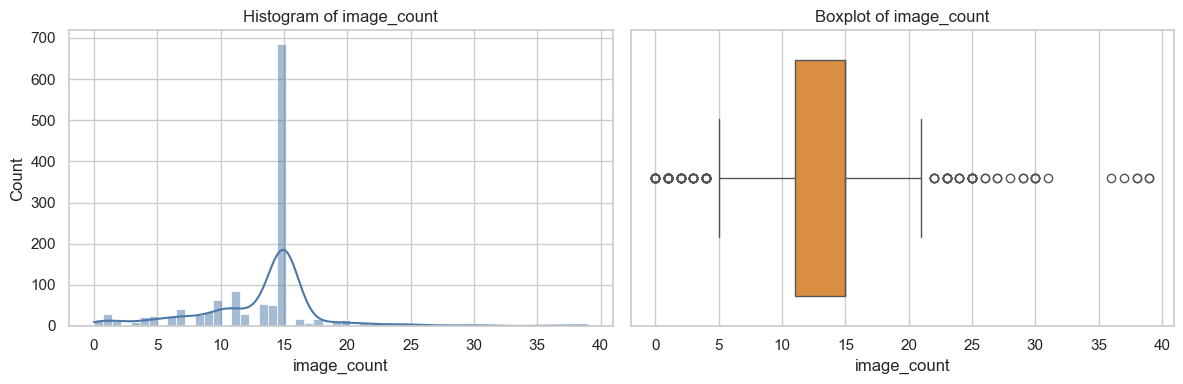

### Distribution: previous_owner_count

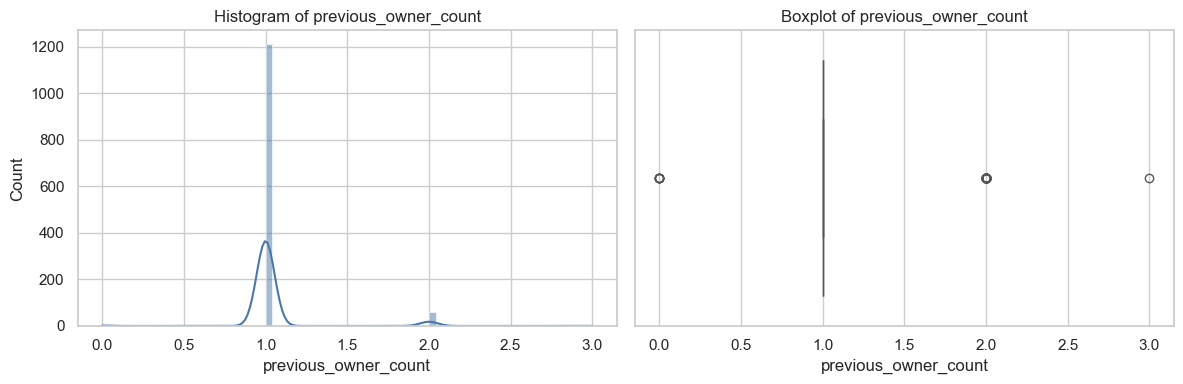

### Distribution: door_count

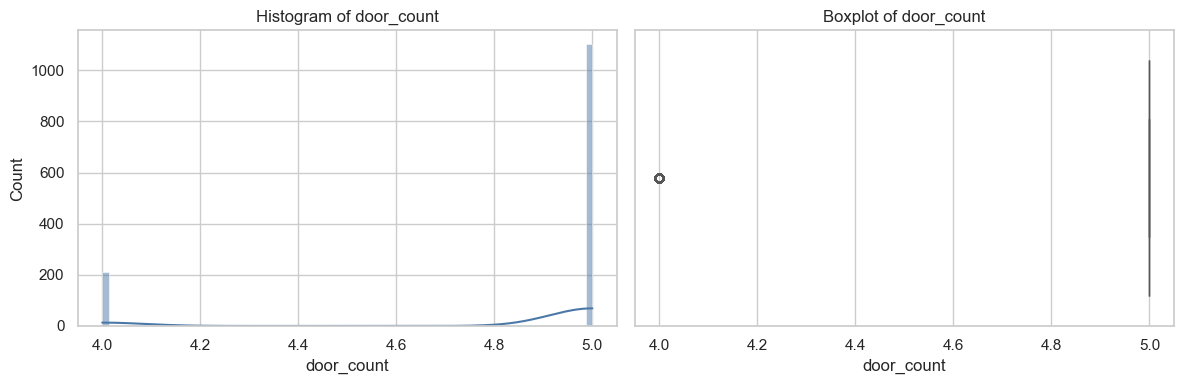

### Distribution: seat_count

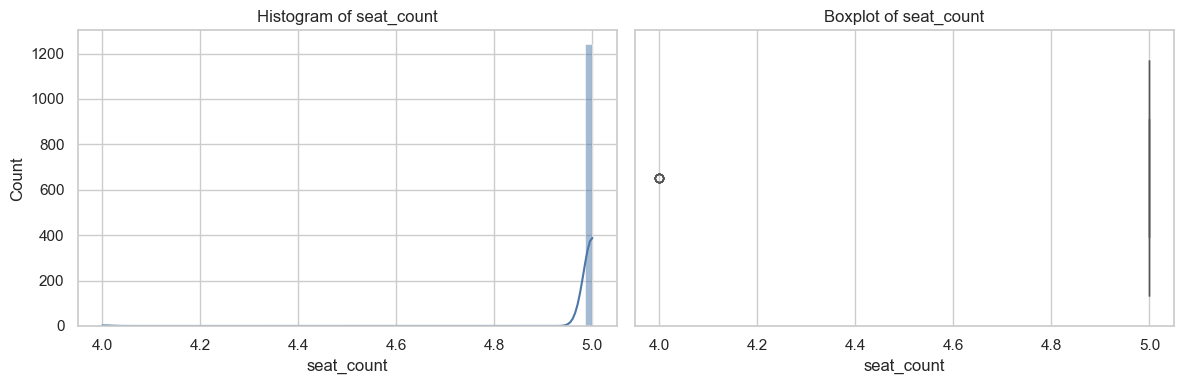

In [9]:
display_section('Numeric field profiling')

numeric_analysis = pd.DataFrame(index=raw_df.index)
numeric_parse_notes = []

for column in NUMERIC_LIKE_COLUMNS:
    if column not in raw_df.columns:
        continue
    numeric_analysis[column] = extract_numeric_series(raw_df[column])
    if not pd.api.types.is_numeric_dtype(raw_df[column]):
        numeric_parse_notes.append(column)

numeric_summary = numeric_analysis.describe().T
numeric_summary['non_null_count'] = numeric_analysis.notna().sum()
numeric_summary['null_pct'] = numeric_analysis.isna().mean() * 100
display(numeric_summary)

display_section(
    'Numeric parsing notes',
    text=(
        'The notebook converts numeric-like text columns in a local analysis copy only. '
        f'Columns parsed from text: {preview_list(numeric_parse_notes)}'
    ),
    level=3,
)

available_numeric_columns = [column for column in numeric_analysis.columns if numeric_analysis[column].notna().any()]

for column in available_numeric_columns:
    display_section(f'Distribution: {column}', level=3)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(numeric_analysis[column].dropna(), kde=True, ax=axes[0], color='#4C78A8')
    axes[0].set_title(f'Histogram of {column}')
    axes[0].set_xlabel(column)
    sns.boxplot(x=numeric_analysis[column].dropna(), ax=axes[1], color='#F28E2B')
    axes[1].set_title(f'Boxplot of {column}')
    axes[1].set_xlabel(column)
    plt.tight_layout()
    plt.show()


## Categorical field profiling

### Secondary detail categorical columns

### Categorical profile: warranty_exists

,count,pct
warranty_exists,,
True,1032,78.122634
False,289,21.877366


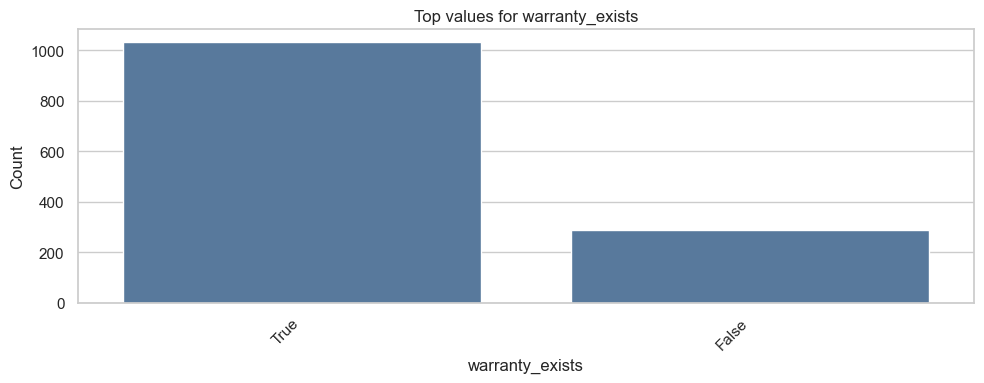

### Categorical profile: has_full_service_history

,count,pct
has_full_service_history,,
True,1090,82.513248
False,230,17.411052
<Missing>,1,0.075700


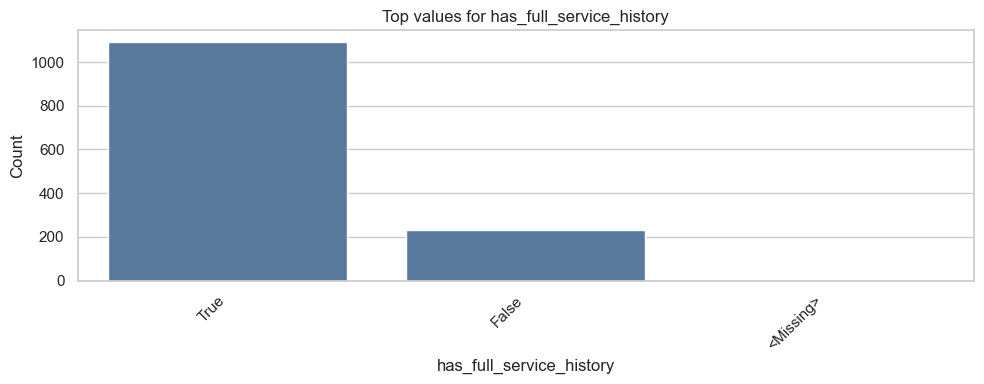

### Categorical profile: had_accident

,count,pct
had_accident,,
False,1173,88.796366
<Missing>,148,11.203634


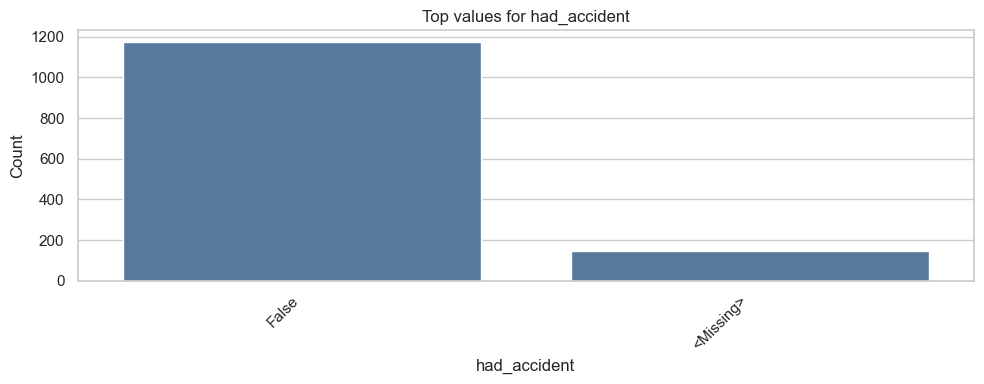

### Categorical profile: damage_conditions

,count,pct
damage_conditions,,
<Missing>,1253,94.852385
Repaired,68,5.147615


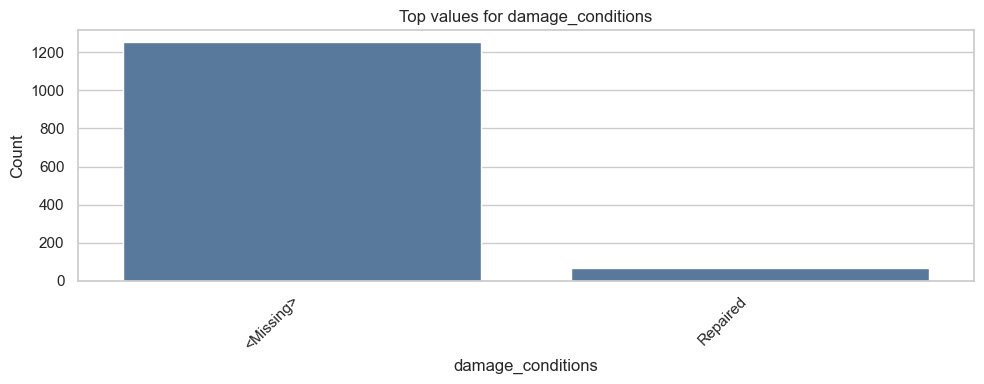

### Categorical profile: body_type

,count,pct
body_type,,
SUV/Off-Road/Pick-Up,1299,98.334595
Coupe,21,1.589705
Compact,1,0.075700


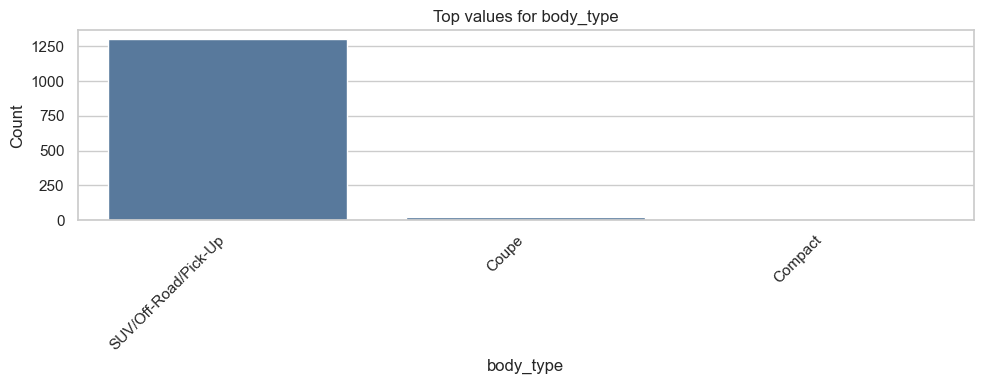

### Categorical profile: exterior_color

,count,pct
exterior_color,,
Grey,485,36.714610
Black,346,26.192279
Blue,212,16.048448
White,177,13.398940
Violet,47,3.557911
Silver,46,3.482210
<Missing>,8,0.605602


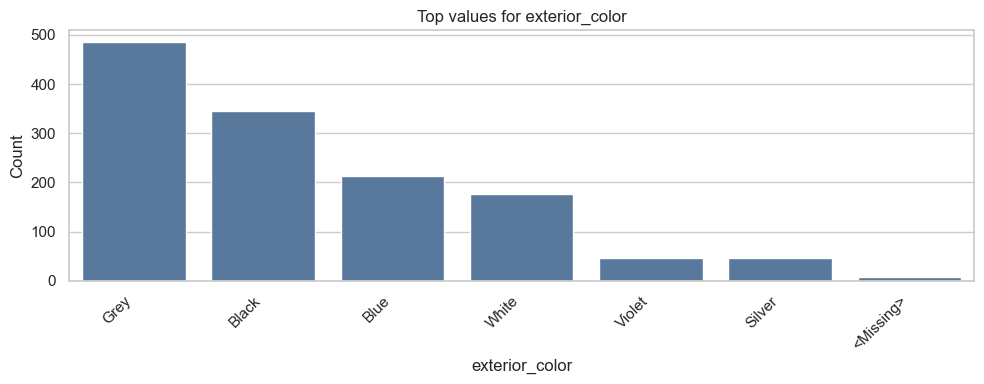

### Categorical profile: paint_type

,count,pct
paint_type,,
Metallic,991,75.018925
Others,170,12.869039
<Missing>,160,12.112036


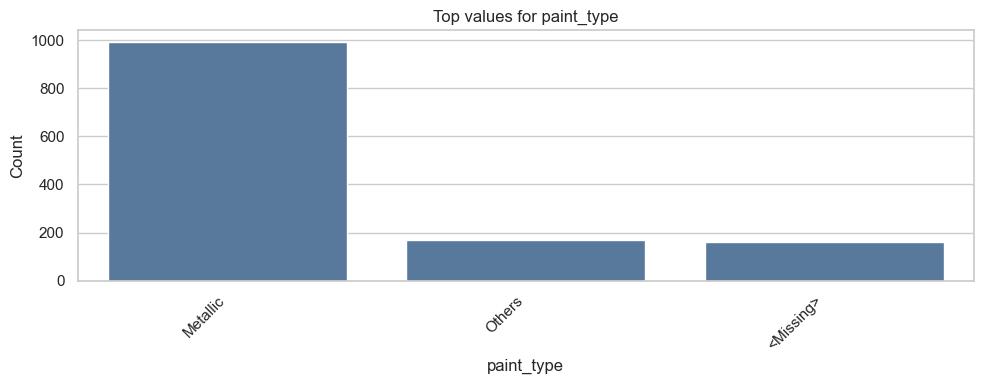

### Categorical profile: interior_color

,count,pct
interior_color,,
Black,1224,92.657078
<Missing>,32,2.422407
Grey,31,2.346707
Beige,13,0.984103
Other,12,0.908403
Brown,7,0.529902
Red,1,0.075700
Blue,1,0.075700


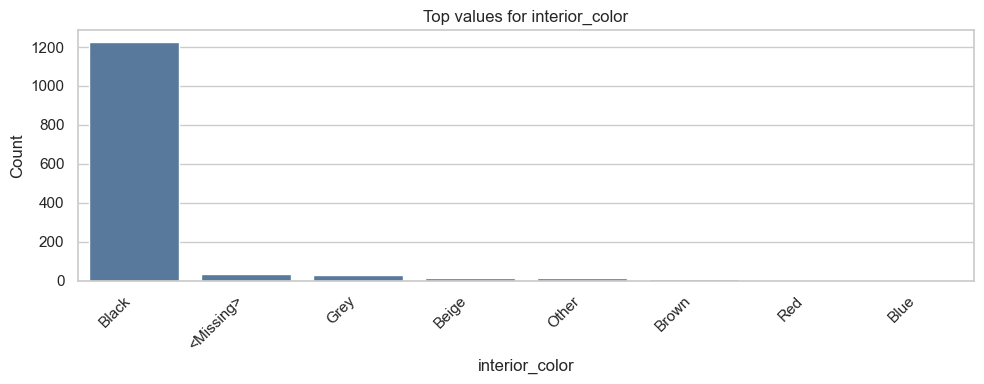

### Categorical profile: upholstery_material

,count,pct
upholstery_material,,
Cloth,788,59.651779
Part leather,246,18.622256
Full leather,190,14.383043
Alcantara,34,2.573808
<Missing>,31,2.346707
Other,31,2.346707
Velour,1,0.075700


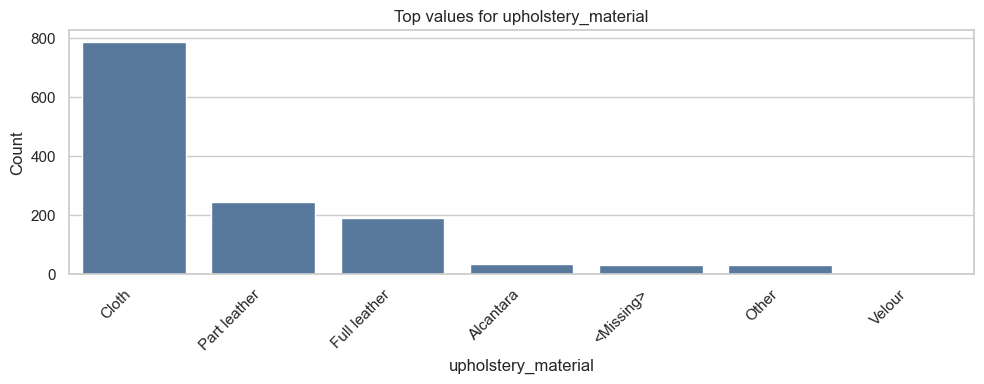

### Categorical profile: battery_ownership

,count,pct
battery_ownership,,
<Missing>,1220,92.354277
Included,101,7.645723


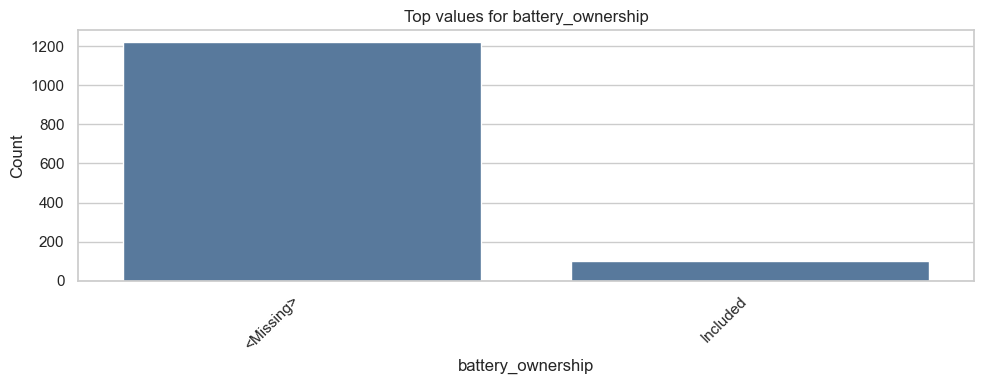

### Inherited context categorical columns

### Categorical profile: seller_type

,count,pct
seller_type,,
Dealer,1289,97.577593
PrivateSeller,32,2.422407


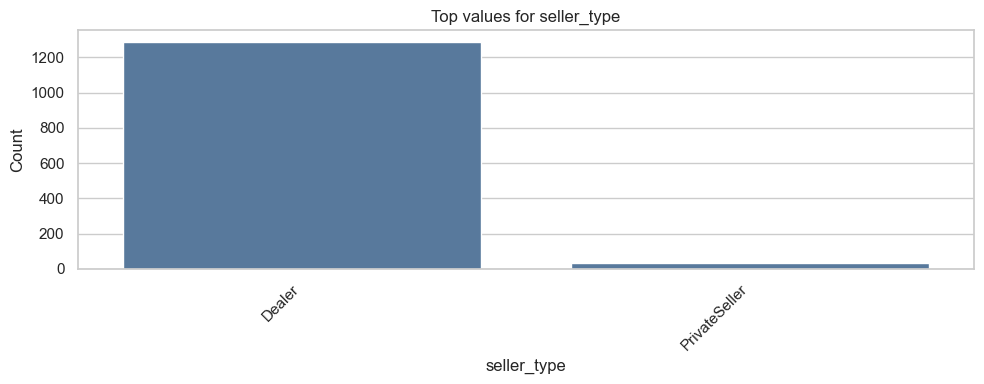

### Categorical profile: country_code

,count,pct
country_code,,
DE,1321,100.0


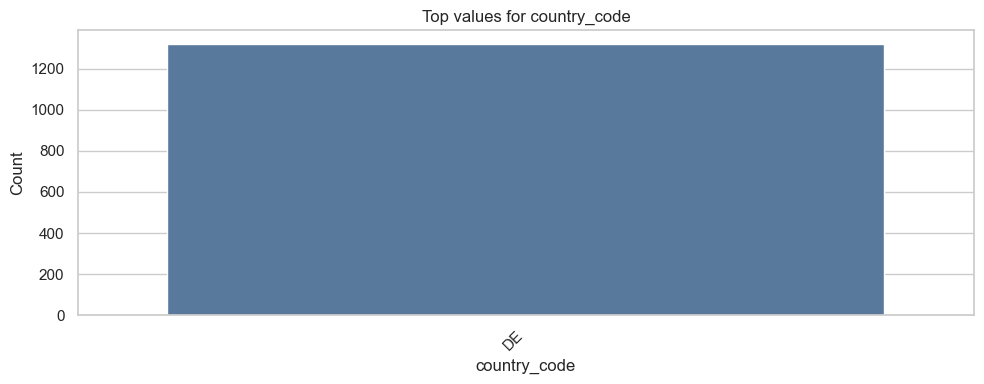

### Categorical profile: fuel_or_powertrain

,count,pct
fuel_or_powertrain,,
Electric,1320,99.9243
Electric/Gasoline,1,0.0757


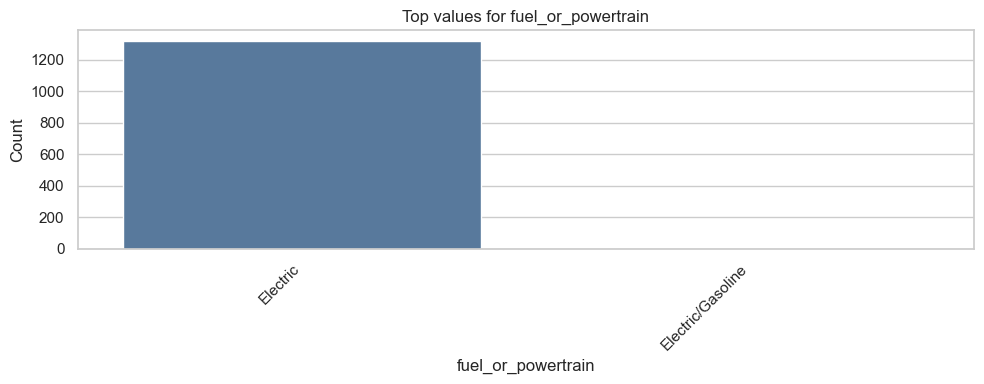

### Categorical profile: variant

,count,pct
variant,,
Q4 e-tron,879,66.5405
Q4 e-tron Sportback,442,33.4595


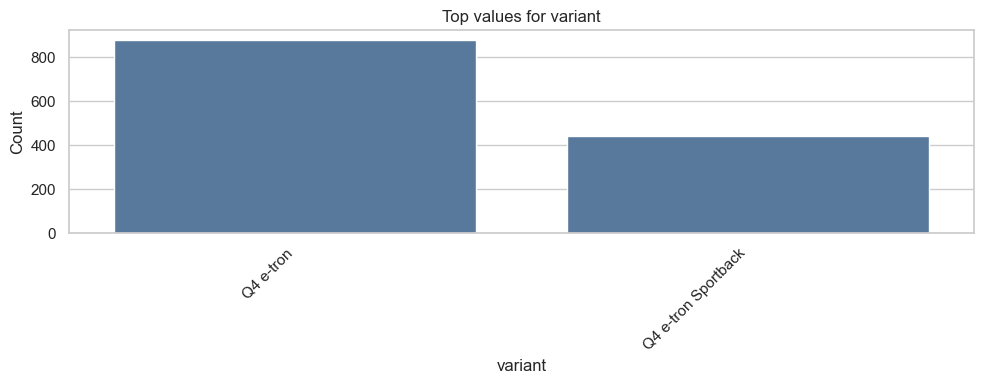

In [10]:
display_section('Categorical field profiling')

display_section('Secondary detail categorical columns', level=3)
for column in SECONDARY_CATEGORICAL_COLUMNS:
    show_top_categories(raw_df, column, top_n=10)

display_section('Inherited context categorical columns', level=3)
for column in INHERITED_CONTEXT_COLUMNS:
    show_top_categories(raw_df, column, top_n=10)


## Targeted cross-field EDA

### Cross-tab: body_type x door_count

door_count,4.0,5.0,<Missing>
body_type,,,
Compact,1,0,0
Coupe,5,16,0
SUV/Off-Road/Pick-Up,204,1085,10


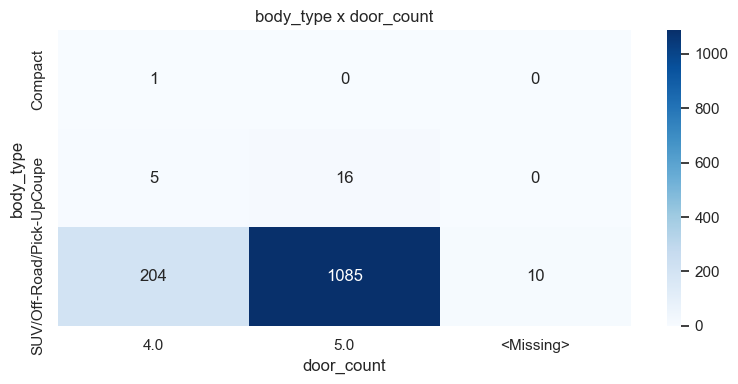

### Cross-tab: body_type x seat_count

seat_count,4.0,5.0,<Missing>
body_type,,,
Compact,0,1,0
Coupe,1,19,1
SUV/Off-Road/Pick-Up,6,1220,73


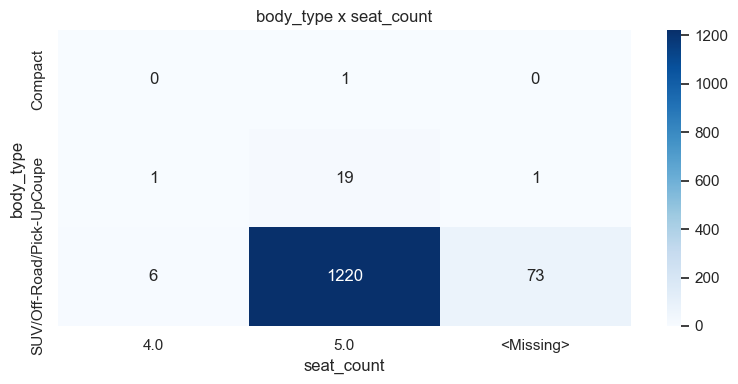

### Cross-tab: exterior_color x interior_color

interior_color,<Missing>,Beige,Black,Blue,Brown,Grey,Other,Red
exterior_color,,,,,,,,
<Missing>,5,0,3,0,0,0,0,0
Black,4,1,323,0,3,12,3,0
Blue,3,4,196,1,2,3,2,1
Grey,17,4,446,0,1,14,3,0
Silver,1,1,43,0,0,0,1,0
Violet,0,2,44,0,1,0,0,0
White,2,1,169,0,0,2,3,0


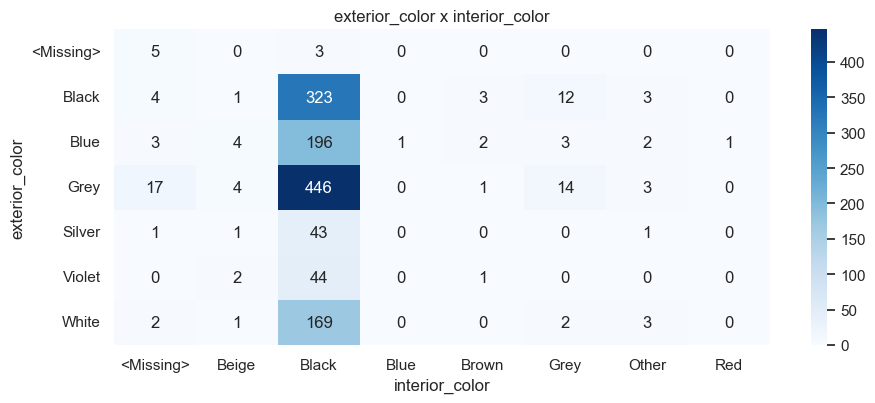

### Cross-tab: paint_type x exterior_color

exterior_color,<Missing>,Black,Blue,Grey,Silver,Violet,White
paint_type,,,,,,,
<Missing>,3,1,2,152,0,0,2
Metallic,4,336,205,182,45,47,172
Others,1,9,5,151,1,0,3


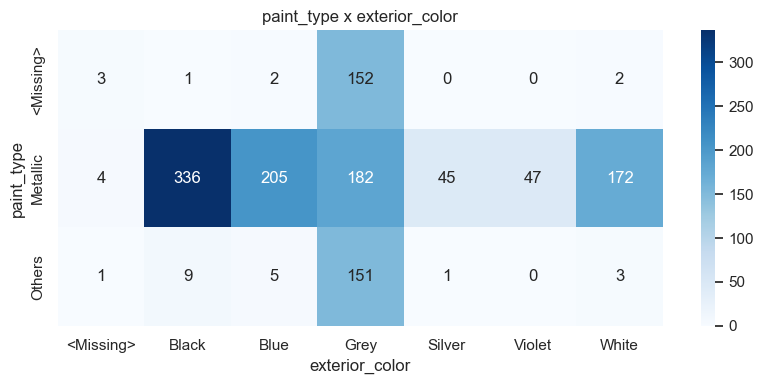

### Cross-tab: had_accident x damage_conditions

damage_conditions,<Missing>,Repaired
had_accident,,
<Missing>,142,6
False,1111,62


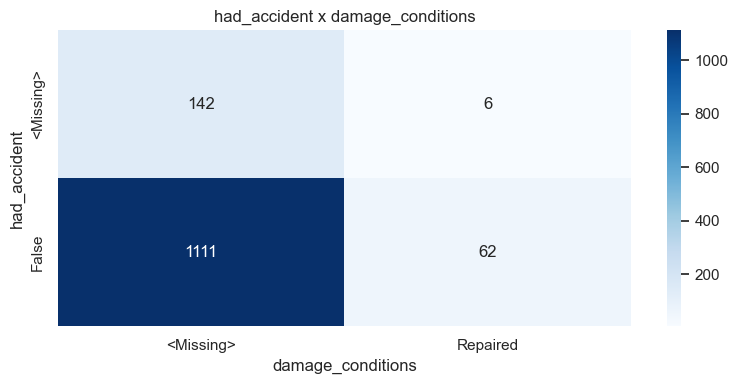

### Cross-tab: warranty_exists x has_full_service_history

has_full_service_history,<Missing>,False,True
warranty_exists,,,
False,1,116,172
True,0,114,918


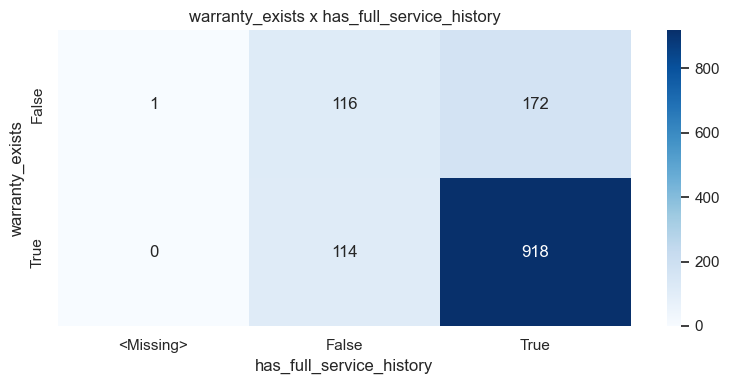

### Cross-tab: seller_type x secondary_scrape_status

secondary_scrape_status,ok
seller_type,
Dealer,1289
PrivateSeller,32


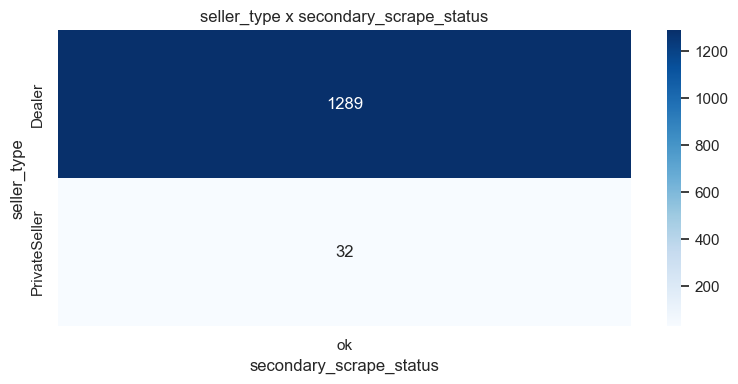

### EV-specific field availability

,column,non_null_count,non_null_pct
0,electric_range,1299,98.334595
1,battery_charging_time,77,5.828917
2,battery_ownership,101,7.645723


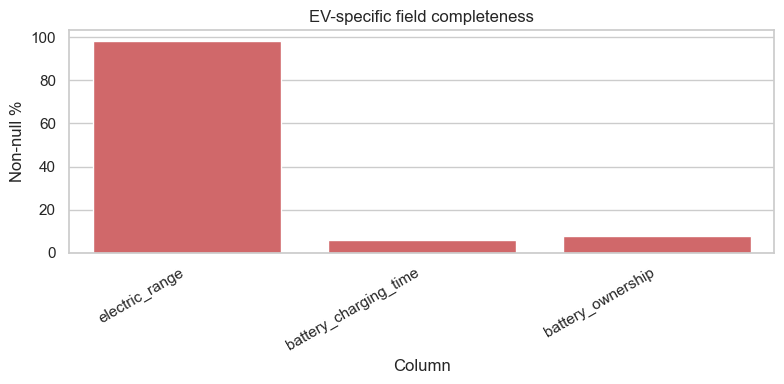

### EV field missingness patterns

,availability_pattern,count,pct
0,1 | 0 | 0,1162,87.963664
1,1 | 0 | 1,60,4.542014
2,1 | 1 | 1,41,3.103709
3,1 | 1 | 0,36,2.725208
4,0 | 0 | 0,22,1.665405


In [11]:
display_section('Targeted cross-field EDA')

show_crosstab(raw_df, 'body_type', 'door_count', top_rows=10, top_cols=10)
show_crosstab(raw_df, 'body_type', 'seat_count', top_rows=10, top_cols=10)
show_crosstab(raw_df, 'exterior_color', 'interior_color', top_rows=10, top_cols=10)
show_crosstab(raw_df, 'paint_type', 'exterior_color', top_rows=10, top_cols=10)
show_crosstab(raw_df, 'had_accident', 'damage_conditions', top_rows=10, top_cols=10)
show_crosstab(raw_df, 'warranty_exists', 'has_full_service_history', top_rows=10, top_cols=10)
show_crosstab(raw_df, 'seller_type', 'secondary_scrape_status', top_rows=10, top_cols=10)

display_section('EV-specific field availability', level=3)
ev_columns = [column for column in ['electric_range', 'battery_charging_time', 'battery_ownership'] if column in raw_df.columns]
ev_availability = pd.DataFrame({
    'column': ev_columns,
    'non_null_count': [raw_df[column].notna().sum() for column in ev_columns],
    'non_null_pct': [raw_df[column].notna().mean() * 100 for column in ev_columns],
})
display(ev_availability)

if ev_columns:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=ev_availability, x='column', y='non_null_pct', color='#E15759')
    plt.title('EV-specific field completeness')
    plt.ylabel('Non-null %')
    plt.xlabel('Column')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    ev_pattern_table = raw_df[ev_columns].notna().astype(int)
    ev_pattern_table.columns = [f'{column}_available' for column in ev_columns]
    ev_patterns = ev_pattern_table.astype(str).agg(' | '.join, axis=1).value_counts().reset_index()
    ev_patterns.columns = ['availability_pattern', 'count']
    ev_patterns['pct'] = ev_patterns['count'] / len(raw_df) * 100
    display_section('EV field missingness patterns', level=3)
    display(ev_patterns.head(10))


## Secondary-field completeness focus

,field_label,column,non_null_count,non_null_pct
0,Warranty,warranty_exists,1321,100.000000
6,Body type,body_type,1321,100.000000
2,Service history,has_full_service_history,1320,99.924300
9,Exterior color,exterior_color,1313,99.394398
7,Doors,door_count,1311,99.242998
15,Electric range,electric_range,1299,98.334595
12,Upholstery,upholstery_material,1290,97.653293
11,Interior color,interior_color,1289,97.577593
5,Previous owners,previous_owner_count,1277,96.669190
8,Seats,seat_count,1247,94.398183


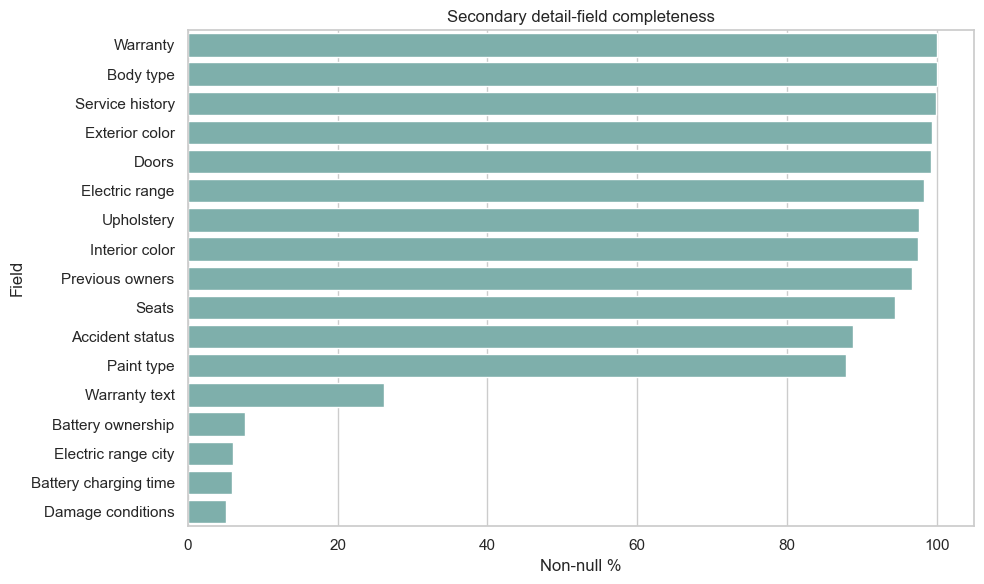

In [12]:
display_section('Secondary-field completeness focus')

completeness_mapping = {
    'Warranty': 'warranty_exists',
    'Warranty text': 'warranty_text',
    'Service history': 'has_full_service_history',
    'Accident status': 'had_accident',
    'Damage conditions': 'damage_conditions',
    'Previous owners': 'previous_owner_count',
    'Body type': 'body_type',
    'Doors': 'door_count',
    'Seats': 'seat_count',
    'Exterior color': 'exterior_color',
    'Paint type': 'paint_type',
    'Interior color': 'interior_color',
    'Upholstery': 'upholstery_material',
    'Battery ownership': 'battery_ownership',
    'Battery charging time': 'battery_charging_time',
    'Electric range': 'electric_range',
    'Electric range city': 'electric_range_city',
}

completeness_rows = []
for label, column in completeness_mapping.items():
    if column not in raw_df.columns:
        continue
    completeness_rows.append({
        'field_label': label,
        'column': column,
        'non_null_count': int(raw_df[column].notna().sum()),
        'non_null_pct': raw_df[column].notna().mean() * 100,
    })

completeness_table = pd.DataFrame(completeness_rows).sort_values('non_null_pct', ascending=False)
display(completeness_table)

plt.figure(figsize=(10, 6))
sns.barplot(data=completeness_table, x='non_null_pct', y='field_label', color='#76B7B2')
plt.title('Secondary detail-field completeness')
plt.xlabel('Non-null %')
plt.ylabel('Field')
plt.tight_layout()
plt.show()


In [13]:
display_section('Preprocessing implications summary')

overall_non_null_pct = raw_df.notna().mean() * 100
mostly_complete_columns = overall_non_null_pct[overall_non_null_pct >= 90].sort_values(ascending=False).index.tolist()
sparse_columns = overall_non_null_pct[overall_non_null_pct < 50].sort_values().index.tolist()

boolean_like_columns = []
for column in raw_df.columns:
    distinct_values = raw_df[column].dropna().astype(str).str.lower().unique().tolist()
    if 0 < len(distinct_values) <= 2:
        boolean_like_columns.append(column)

numeric_text_candidates = [
    column for column in NUMERIC_LIKE_COLUMNS + ['electric_range']
    if column in raw_df.columns and not pd.api.types.is_numeric_dtype(raw_df[column])
]

secondary_missing_strategy_columns = []
if len(completeness_table):
    secondary_missing_strategy_columns = completeness_table.loc[
        completeness_table['non_null_pct'] < 90,
        'column',
    ].tolist()

summary_markdown = f"""
### Key EDA takeaways before preprocessing

- Mostly complete columns (>=90% non-null): {preview_list(mostly_complete_columns)}
- Sparse columns (<50% non-null): {preview_list(sparse_columns)}
- Mostly boolean/binary-like columns: {preview_list(boolean_like_columns)}
- Columns that may need text-to-numeric parsing: {preview_list(numeric_text_candidates)}
- Secondary detail fields that may need explicit missing-value decisions: {preview_list(secondary_missing_strategy_columns)}

### Recommended preprocessing follow-up themes

- Normalize numeric-like text fields into analysis-ready numeric columns without overwriting raw source values.
- Decide how to treat sparse EV-specific fields such as charging-time related attributes.
- Review low-frequency categorical values before encoding or grouping rare categories.
- Confirm how scrape-error rows should be handled before downstream analytics or modeling.
"""

display(Markdown(summary_markdown))


## Preprocessing implications summary


### Key EDA takeaways before preprocessing

- Mostly complete columns (>=90% non-null): listing_id, power_hp, body_type, warranty_exists, listing_url, image_count, city, zip_code, country_code, seller_location, title, dealer_id, ... (+31 more)
- Sparse columns (<50% non-null): vat_deductible, secondary_scrape_error, delivery_possible, has_360_image, raw_card_text, damage_conditions, battery_charging_time, electric_range_city, battery_ownership, warranty_text, wltp_consumption, wltp_co2_emissions
- Mostly boolean/binary-like columns: variant, model_group, transmission, currency, price_superscript, is_conditional_price, fuel_or_powertrain, seller_type, country_code, has_360_image, available_now, delivery_possible, ... (+9 more)
- Columns that may need text-to-numeric parsing: price, electric_range
- Secondary detail fields that may need explicit missing-value decisions: had_accident, paint_type, warranty_text, battery_ownership, electric_range_city, battery_charging_time, damage_conditions

### Recommended preprocessing follow-up themes

- Normalize numeric-like text fields into analysis-ready numeric columns without overwriting raw source values.
- Decide how to treat sparse EV-specific fields such as charging-time related attributes.
- Review low-frequency categorical values before encoding or grouping rare categories.
- Confirm how scrape-error rows should be handled before downstream analytics or modeling.
